# GenAI-Net (RL4CRN) — Unified Tasks + Training Tutorial

This notebook **merges**:
1) the **Task Presets / TaskSpec factory** tutorial (logic, tracking, oscillator, dose-response, SSA)  
2) the **minimal training** tutorial (session + trainer, stop/resume, checkpoints)

The goal is to **exercise the full stack**:
- task construction (`make_task`)
- session wiring (`make_session_and_trainer`)
- training loop (`trainer.run`, `trainer.step_epoch`)
- inspection (`trainer.inspect_best`)
- checkpoint save/load

---
## 0) Environment setup

From repo root:

```bash
pip install -e .
```


In [1]:
import os
import sys
import numpy as np

print("Python:", sys.version.split()[0])
print("CWD:", os.getcwd())

Python: 3.10.12
CWD: /local0/rossin/git/CRN-GenerativeAI/tutorial


---
## 1) Imports

We use the **standard interface layer** in `RL4CRN/utils/input_interface.py`:
- `Configurator`: presets + overrides
- `make_task`: standardized task builder
- `make_session_and_trainer`: full wiring (template/library/env/interfaces/policy/agent/trainer)


In [2]:
from RL4CRN.utils.input_interface import (
    Configurator,
    make_task,
    make_session_and_trainer,
)

from RL4CRN.utils.visualizations import plot_truth_table

---
## 2) Helper utilities (notebook-local)

A few tiny helpers for clean display and consistent smoke tests.


In [3]:
def print_task_summary(task, max_preview=3):
    """Print a compact TaskSpec summary."""
    print("Task:", task.name)
    print("time_horizon:", task.time_horizon.shape, f"[0..{task.time_horizon[-1]}]")
    print("num scenarios:", len(task.u_list))
    if len(task.u_list) > 0:
        print(f"first {min(max_preview, len(task.u_list))} u:", task.u_list[:max_preview])
    print()


def run_smoke_reward(task, state, label=""):
    """Call task.compute_reward on a given state and print normalized output."""
    out = task.compute_reward(state)
    if isinstance(out, tuple):
        loss, info = out
    else:
        loss, info = out, {}
    print(f"[reward smoke{(' - ' + label) if label else ''}] loss={float(loss):.6g} | info_keys={list(info.keys())[:8]}")
    return out

---
## 3) Task factory demo (no training yet)

This section mirrors the "Task Presets Tutorial" idea: construct tasks with a few knobs.
Here we build tasks **standalone** (no environments), just to show the API and validate object shapes.


In [4]:
species_labels_logic = [f"X_{i+1}" for i in range(3)] + ["OUT"]
species_labels_rpa   = ["X_1", "X_2", "X_3", "X_4", "X_5", "X_6", "OUT"]
species_labels_osc   = ["X_1", "X_2", "X_3"]
species_labels_dose  = ["X_1", "X_2", "OUT"]

print("Logic labels:", species_labels_logic)
print("RPA labels:", species_labels_rpa)
print("Osc labels:", species_labels_osc)
print("Dose labels:", species_labels_dose)

Logic labels: ['X_1', 'X_2', 'X_3', 'OUT']
RPA labels: ['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'OUT']
Osc labels: ['X_1', 'X_2', 'X_3']
Dose labels: ['X_1', 'X_2', 'OUT']


### 3.1) Logic task

In [5]:
logic_fn = lambda u: (bool(u[0]) and (not bool(u[1]))) or bool(u[2])

task_logic = make_task(
    kind="logic",
    species_labels=species_labels_logic,
    n_inputs=3,
    logic_fn=logic_fn,
    ic="zero",
    weights="steady_state",
    t_f=100, n_t=200,
)
print_task_summary(task_logic)

# Plot truth table target (reconstruct r_list for visualization)
r_list = [np.array([float(bool(logic_fn(u)))], dtype=np.float32) for u in task_logic.u_list]
plot_truth_table(task_logic.u_list, r_list, title="Target truth table (logic task)")
pass

TypeError: make_task() got an unexpected keyword argument 'n_inputs'

### 3.2) Deterministic tracking (RPA-style)

In [ ]:
task_tracking = make_task(
    kind="tracking",
    species_labels=species_labels_rpa,
    p=3,
    u_values=[0.5, 1.0, 1.5],
    target="copy_input0",
    ic=("constant", 0.01),
    weights="transient",
    t_f=100, n_t=200,
)
print_task_summary(task_tracking)

Task: tracking
time_horizon: (200,) [0..100.0]
num scenarios: 27
first 3 u: [array([0.5, 0.5, 0.5], dtype=float32), array([0.5, 0.5, 1. ], dtype=float32), array([0.5, 0.5, 1.5], dtype=float32)]



### 3.3) Oscillator discovery (mean-level targeting)

In [ ]:
task_osc = make_task(
    kind="oscillator",
    species_labels=species_labels_osc,
    p=1,
    u_values=[1.0],
    ic=("constant", 0.01),
    t_f=100, n_t=200,
    osc_w=[0.4, 0.0, 0.2, 0.4],
    t0=20.0,
)
print_task_summary(task_osc)

Task: oscillator
time_horizon: (200,) [0..100.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]



### 3.4) Dose–response matching (target is a function)

In [ ]:
def hill_function(u: float, kd=5.0, max_production=50.0, n=6.0) -> float:
    return max_production * (u**n) / (kd**n + u**n)

task_dose = make_task(
    kind="dose_response",
    species_labels=species_labels_dose,
    dose_range=(0.0, 10.0, 10),
    target_fn=hill_function,
    ic=("constant", 0.1),
    weights="transient",
    t_f=100, n_t=200,
)
print_task_summary(task_dose)

Task: dose_response
time_horizon: (200,) [0..100.0]
num scenarios: 10
first 3 u: [array([0.], dtype=float32), array([1.1111112], dtype=float32), array([2.2222223], dtype=float32)]



### 3.5) Stochastic SSA tracking (smoke only)

In [ ]:
task_ssa = make_task(
    kind="ssa_tracking",
    species_labels=species_labels_rpa,
    p=2,
    u_values=[1.0, 2.0, 3.0],
    target="copy_input0",
    ic="zero",
    weights="steady_state",
    t_f=50, n_t=100,
    n_trajectories=64,
    max_threads=1024,
)
print_task_summary(task_ssa)

Task: ssa_tracking
time_horizon: (100,) [0..50.0]
num scenarios: 9
first 3 u: [array([1., 1.], dtype=float32), array([1., 2.], dtype=float32), array([1., 3.], dtype=float32)]



### 3.6) Robust SSA (smoke only)

In [ ]:
task_ssa_robust = make_task(
    kind="ssa_robust",
    species_labels=species_labels_rpa,
    p=2,
    u_values=[1.0, 2.0, 3.0],
    target="copy_input0",
    ic="zero",
    weights="steady_state",
    t_f=50, n_t=100,
    n_trajectories=64,
    max_threads=1024,
    rpa_weight=3.0,
    cv_weight=1.0,
)
print_task_summary(task_ssa_robust)

Task: ssa_robust
time_horizon: (100,) [0..50.0]
num scenarios: 9
first 3 u: [array([1., 1.], dtype=float32), array([1., 2.], dtype=float32), array([1., 3.], dtype=float32)]



---
## 4) Full wiring + training (logic task)

This section mirrors the older training notebook, but uses the updated session object:
- `session.task.u_list` instead of `session.u_list`
- `session.task.compute_reward` is used by the environment via `Trainer`


In [ ]:
cfg = Configurator.preset("fast")

# Task config
cfg.task.kind = "logic"
cfg.task.n_inputs = 3
cfg.task.logic_fn = lambda u: (bool(u[0]) and (not bool(u[1]))) or bool(u[2])
cfg.task.t_f = 100.0
cfg.task.N_t = 200
cfg.task.weights = "steady_state"
cfg.task.ic_value = 0.01

# Train config
cfg.train.max_added_reactions = 5
cfg.train.epochs = 30
cfg.train.render_every = 5
cfg.train.seed = 0

# Library / solver
cfg.library.order = 2
cfg.library.include_dilution = False
cfg.solver.algorithm = "CVODE"
cfg.solver.rtol = 1e-10
cfg.solver.atol = 1e-10

Device: cuda
CPUs: 128 | Batch size: 1280
Task: logic | Inputs: 3 | Max steps: 5



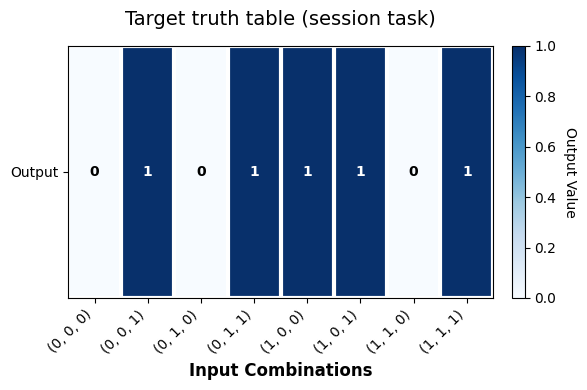

Template IO-CRN:
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]


In [ ]:
session, trainer = make_session_and_trainer(cfg, device="auto")

print(f"Device: {session.device}")
print(f"CPUs: {session.n_cpus} | Batch size: {session.batch_size}")
print(f"Task: {session.task.name} | Inputs: {cfg.task.n_inputs} | Max steps: {cfg.train.max_added_reactions}")
print()

# Plot target truth table
u_list = session.task.u_list
r_list = [np.array([float(bool(cfg.task.logic_fn(u)))], dtype=np.float32) for u in u_list]
plot_truth_table(u_list, r_list, title="Target truth table (session task)")

print("Template IO-CRN:")
print(session.crn_template)

### 4.1) Reward smoke test on template state

In [ ]:
run_smoke_reward(session.task, session.crn_template, label="template")

[reward smoke - template] loss=0.6225 | info_keys=['type', 'inputs', 'initial conditions', 'time_horizon', 'trajectories', 'outputs', 'reward', 'setpoint']


(0.6225,
 {'type': 'transient response',
  'inputs': [array([0., 0., 0.], dtype=float32),
   array([0., 0., 1.], dtype=float32),
   array([0., 1., 0.], dtype=float32),
   array([0., 1., 1.], dtype=float32),
   array([1., 0., 0.], dtype=float32),
   array([1., 0., 1.], dtype=float32),
   array([1., 1., 0.], dtype=float32),
   array([1., 1., 1.], dtype=float32)],
  'initial conditions': [array([0.01, 0.01, 0.01, 0.01])],
  'time_horizon': array([  0.       ,   0.5025126,   1.0050251,   1.5075377,   2.0100503,
           2.5125628,   3.0150754,   3.517588 ,   4.0201006,   4.522613 ,
           5.0251255,   5.527638 ,   6.030151 ,   6.5326633,   7.035176 ,
           7.5376883,   8.040201 ,   8.542713 ,   9.045226 ,   9.547739 ,
          10.050251 ,  10.552764 ,  11.055276 ,  11.557789 ,  12.060302 ,
          12.562814 ,  13.065327 ,  13.56784  ,  14.070352 ,  14.572865 ,
          15.0753765,  15.577889 ,  16.080402 ,  16.582914 ,  17.085426 ,
          17.58794  ,  18.090452 ,  18.5929

### 4.2) Train (stop/resume friendly)

- `trainer.run(...)` supports Ctrl+C  
- pass `checkpoint_path` to save periodically and on interrupt


In [ ]:
checkpoint_path = "logic_chkpt.pkl"
trainer.run(epochs=cfg.train.epochs, checkpoint_path=checkpoint_path)


[cvHandleFailure, Error: -15] At t = 46.2623447226662, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 16.4845885180292, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 19.2880277631486, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.8381226160093, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.83812774447084, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 17.502481980281, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 17.4444095952448, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 13.1692274688946, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 18.3437501292277, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.50121566534003, unable to satisfy inequality constraints.


[cvHandleFa

Best loss: 0.10566472885120225
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> X_1 + X_2;  [MAK(0.6960989236831665)]
X_1 + X_3 ----> OUT + X_3;  [MAK(0.15445607900619507)]
OUT + X_2 ----> X_1;  [MAK(0.7039704918861389)]
X_3 + X_3 ----> X_2 + X_2;  [MAK(0.5728987455368042)]
OUT + OUT ----> X_2 + X_3;  [MAK(0.8416049480438232)]


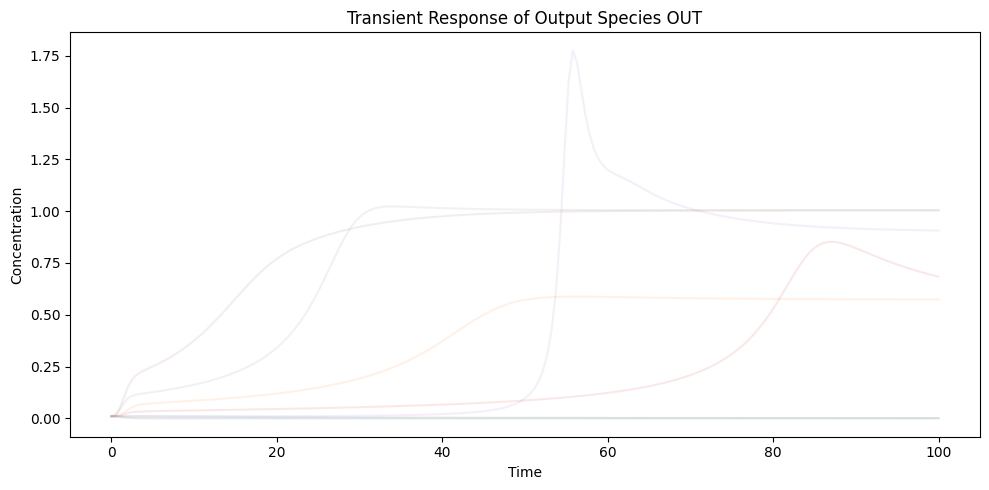

In [ ]:
trainer.inspect_best(plot=True)

In [ ]:
best = trainer.best_crn()
print("Hall of Fame size:", len(session.mult_env.hall_of_fame))
if best is not None:
    print("Best loss:", best.last_task_info.get("reward", None))

Hall of Fame size: 30
Best loss: 0.10566472885120225


### 4.3) Checkpoint load (resume workflow)

Rebuild session/trainer, then load.


Loaded checkpoint: logic_chkpt.pkl (epoch=4) | restored_hof=30
Best loss: 0.10566472885120225
Inputs: ['u_1', 'u_2', 'u_3'] 
Species: ['OUT', 'X_1', 'X_2', 'X_3'] 
Output Species: ['OUT'] 
∅ ----> X_1;  [MAK(1.0, u_1)]
∅ ----> X_2;  [MAK(1.0, u_2)]
∅ ----> X_3;  [MAK(1.0, u_3)]
X_3 ----> X_1 + X_2;  [MAK(0.6960989236831665)]
X_1 + X_3 ----> OUT + X_3;  [MAK(0.15445607900619507)]
OUT + X_2 ----> X_1;  [MAK(0.7039704918861389)]
X_3 + X_3 ----> X_2 + X_2;  [MAK(0.5728987455368042)]
OUT + OUT ----> X_2 + X_3;  [MAK(0.8416049480438232)]


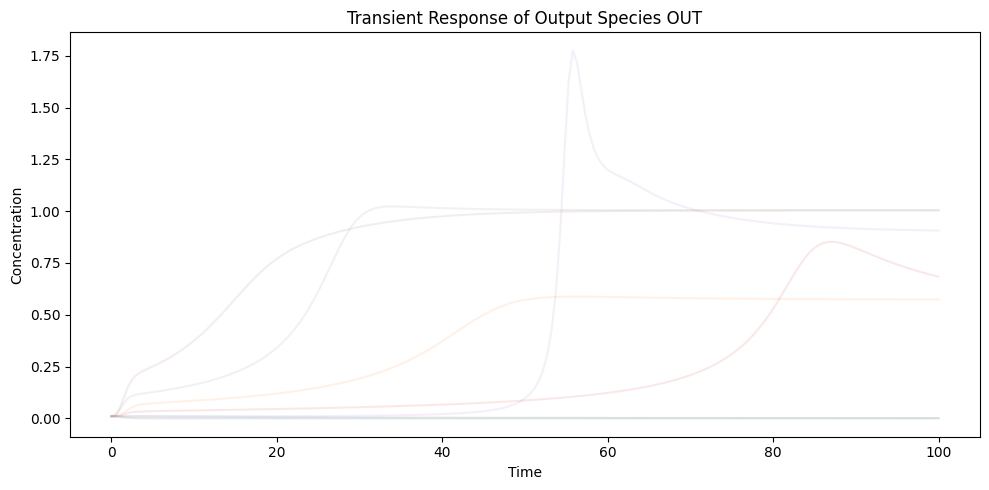

In [ ]:
session2, trainer2 = make_session_and_trainer(cfg, device="auto")
trainer2.load(checkpoint_path)
trainer2.inspect_best(plot=True)

---
## 5) Full wiring smoke tests for other tasks

We keep these tests short:
- build a session
- run a reward smoke test on the template
- run a couple of training epochs (deterministic tasks only)

For SSA tasks, reward can be expensive; we only do reward smoke tests by default.


In [ ]:
cfg_tr = Configurator.preset("fast")
cfg_tr.task.kind = "tracking"
cfg_tr.task.n_inputs = 3
cfg_tr.task.t_f = 50.0
cfg_tr.task.N_t = 120
cfg_tr.task.weights = "transient"
cfg_tr.task.target = "copy_input0"
cfg_tr.task.ic_value = 0.01

cfg_tr.train.max_added_reactions = 4
cfg_tr.train.epochs = 5
cfg_tr.train.render_every = 1
cfg_tr.train.seed = 1

session_tr, trainer_tr = make_session_and_trainer(cfg_tr, device="auto")

print("=== Tracking task wiring ===")
print_task_summary(session_tr.task)
run_smoke_reward(session_tr.task, session_tr.crn_template, label="tracking template")

trainer_tr.run(epochs=cfg_tr.train.epochs, checkpoint_path=None)
trainer_tr.inspect_best(plot=True)

=== Tracking task wiring ===
Task: tracking
time_horizon: (120,) [0..50.0]
num scenarios: 1
first 1 u: [array([1., 1., 1.], dtype=float32)]

[reward smoke - tracking template] loss=1.0395 | info_keys=['type', 'inputs', 'initial conditions', 'time_horizon', 'trajectories', 'outputs', 'reward', 'setpoint']

[cvHandleFailure, Error: -15] At t = 6.84195033969455, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 12.5927936116969, unable to satisfy inequality constraints.

[epoch 0] best loss=0.01009 | median loss=1.05
[epoch 1] best loss=0.0135 | median loss=1.05

[cvHandleFailure, Error: -15] At t = 13.3339591206568, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 7.01930246846023, unable to satisfy inequality constraints.

[epoch 2] best loss=0.01517 | median loss=1.05
[epoch 3] best loss=0.009233 | median loss=1.05

[cvHandleFailure, Error: -15] At t = 16.1230951851205, unable to satisfy inequality constraints.


[cvHandleF

=== Oscillator task wiring ===
Task: oscillator
time_horizon: (120,) [0..50.0]
num scenarios: 1
first 1 u: [array([1.], dtype=float32)]

[reward smoke - oscillator template] loss=0.996 | info_keys=['type', 'inputs', 'initial conditions', 'time_horizon', 'trajectories', 'outputs', 'reward', 'frequency']

[cvHandleFailure, Error: -15] At t = 4.99581432617965, unable to satisfy inequality constraints.

[epoch 0] best loss=0.6 | median loss=1

[cvHandleFailure, Error: -15] At t = 2.50059737330783, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 22.0686077066814, unable to satisfy inequality constraints.


[cvHandleFailure, Error: -15] At t = 5.63423604437337, unable to satisfy inequality constraints.

[epoch 1] best loss=0.6007 | median loss=1

[cvHandleFailure, Error: -15] At t = 5.61209235441109, unable to satisfy inequality constraints.

[epoch 2] best loss=0.6002 | median loss=1

[cvHandleFailure, Error: -15] At t = 7.85918467632873, unable to satisfy i

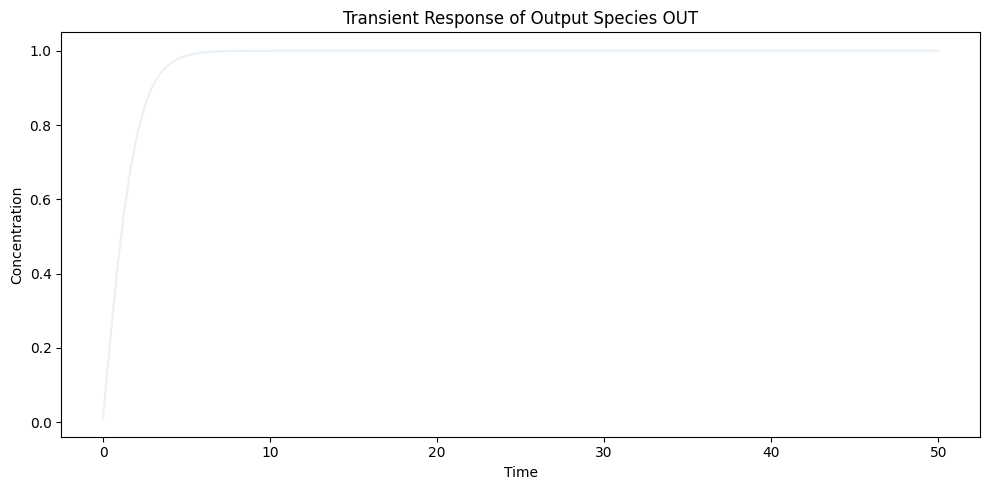

In [ ]:
cfg_osc = Configurator.preset("fast")
cfg_osc.task.kind = "oscillator"
cfg_osc.task.n_inputs = 1
cfg_osc.task.t_f = 50.0
cfg_osc.task.N_t = 120
cfg_osc.task.ic_value = 0.01

cfg_osc.train.max_added_reactions = 4
cfg_osc.train.epochs = 5
cfg_osc.train.render_every = 1
cfg_osc.train.seed = 2

session_osc, trainer_osc = make_session_and_trainer(cfg_osc, device="auto")

print("=== Oscillator task wiring ===")
print_task_summary(session_osc.task)
run_smoke_reward(session_osc.task, session_osc.crn_template, label="oscillator template")

trainer_osc.run(epochs=cfg_osc.train.epochs, checkpoint_path=None)
trainer_osc.inspect_best(plot=True)

In [ ]:
cfg_dose = Configurator.preset("fast")
cfg_dose.task.kind = "dose_response"
cfg_dose.task.n_inputs = 1
cfg_dose.task.t_f = 50.0
cfg_dose.task.N_t = 120
cfg_dose.task.ic_value = 0.1
cfg_dose.task.weights = "transient"
cfg_dose.task.target_fn = lambda u: hill_function(u, kd=5.0, max_production=50.0, n=6.0)
cfg_dose.task.dose_range = (0.0, 10.0, 10)

session_dose, trainer_dose = make_session_and_trainer(cfg_dose, device="auto")

print("=== Dose-response task wiring (reward smoke only) ===")
print_task_summary(session_dose.task)
run_smoke_reward(session_dose.task, session_dose.crn_template, label="dose template")

ValueError: dose_response needs target_fn(u)->y*.

In [ ]:
cfg_ssa = Configurator.preset("fast")
cfg_ssa.task.kind = "ssa_tracking"
cfg_ssa.task.n_inputs = 2
cfg_ssa.task.t_f = 30.0
cfg_ssa.task.N_t = 80
cfg_ssa.task.ic_value = 0.0
cfg_ssa.task.weights = "steady_state"
cfg_ssa.task.target = "copy_input0"

session_ssa, trainer_ssa = make_session_and_trainer(cfg_ssa, device="auto")

print("=== SSA tracking task wiring (reward smoke only) ===")
print_task_summary(session_ssa.task)
run_smoke_reward(session_ssa.task, session_ssa.crn_template, label="ssa tracking template")

=== SSA tracking task wiring (reward smoke only) ===
Task: ssa_tracking
time_horizon: (80,) [0..30.0]
num scenarios: 1
first 1 u: [array([1., 1.], dtype=float32)]

[reward smoke - ssa tracking template] loss=1 | info_keys=['type', 'inputs', 'initial conditions', 'time_horizon', 'trajectories', 'trajectories_std', 'outputs', 'outputs_std']


(1.0,
 {'type': 'transient response SSA',
  'inputs': [array([1., 1.], dtype=float32)],
  'initial conditions': [array([0., 0., 0.])],
  'time_horizon': array([ 0.        ,  0.37974682,  0.75949365,  1.1392405 ,  1.5189873 ,
          1.8987342 ,  2.278481  ,  2.658228  ,  3.0379746 ,  3.4177215 ,
          3.7974684 ,  4.177215  ,  4.556962  ,  4.936709  ,  5.316456  ,
          5.6962028 ,  6.075949  ,  6.455696  ,  6.835443  ,  7.21519   ,
          7.594937  ,  7.974684  ,  8.35443   ,  8.734178  ,  9.113924  ,
          9.49367   ,  9.873418  , 10.253164  , 10.632912  , 11.012658  ,
         11.3924055 , 11.772152  , 12.151898  , 12.531646  , 12.911392  ,
         13.29114   , 13.670886  , 14.050632  , 14.43038   , 14.810126  ,
         15.189874  , 15.56962   , 15.949368  , 16.329113  , 16.70886   ,
         17.088608  , 17.468355  , 17.8481    , 18.227848  , 18.607595  ,
         18.98734   , 19.367088  , 19.746836  , 20.126583  , 20.506329  ,
         20.886076  , 21.265823  , 

In [ ]:
cfg_ssa_r = Configurator.preset("fast")
cfg_ssa_r.task.kind = "ssa_robust"
cfg_ssa_r.task.n_inputs = 2
cfg_ssa_r.task.t_f = 30.0
cfg_ssa_r.task.N_t = 80
cfg_ssa_r.task.ic_value = 0.0
cfg_ssa_r.task.weights = "steady_state"
cfg_ssa_r.task.target = "copy_input0"

session_ssa_r, trainer_ssa_r = make_session_and_trainer(cfg_ssa_r, device="auto")

print("=== SSA robust task wiring (reward smoke only) ===")
print_task_summary(session_ssa_r.task)
run_smoke_reward(session_ssa_r.task, session_ssa_r.crn_template, label="ssa robust template")

=== SSA robust task wiring (reward smoke only) ===
Task: ssa_robust
time_horizon: (80,) [0..30.0]
num scenarios: 1
first 1 u: [array([1., 1.], dtype=float32)]

[reward smoke - ssa robust template] loss=1 | info_keys=['type', 'inputs', 'initial conditions', 'time_horizon', 'trajectories', 'trajectories_std', 'outputs', 'outputs_std']


(1.0,
 {'type': 'transient response SSA',
  'inputs': [array([1., 1.], dtype=float32)],
  'initial conditions': [array([0., 0., 0.])],
  'time_horizon': array([ 0.        ,  0.37974682,  0.75949365,  1.1392405 ,  1.5189873 ,
          1.8987342 ,  2.278481  ,  2.658228  ,  3.0379746 ,  3.4177215 ,
          3.7974684 ,  4.177215  ,  4.556962  ,  4.936709  ,  5.316456  ,
          5.6962028 ,  6.075949  ,  6.455696  ,  6.835443  ,  7.21519   ,
          7.594937  ,  7.974684  ,  8.35443   ,  8.734178  ,  9.113924  ,
          9.49367   ,  9.873418  , 10.253164  , 10.632912  , 11.012658  ,
         11.3924055 , 11.772152  , 12.151898  , 12.531646  , 12.911392  ,
         13.29114   , 13.670886  , 14.050632  , 14.43038   , 14.810126  ,
         15.189874  , 15.56962   , 15.949368  , 16.329113  , 16.70886   ,
         17.088608  , 17.468355  , 17.8481    , 18.227848  , 18.607595  ,
         18.98734   , 19.367088  , 19.746836  , 20.126583  , 20.506329  ,
         20.886076  , 21.265823  , 

---
## 6) Appendix: all tunable knobs

Everything in the config is editable; the preset only sets defaults.


In [ ]:
cfg.describe()

{'task': {'kind': 'logic',
          'n_inputs': 3,
          'logic_fn': <function <lambda> at 0x7f2504e05b40>,
          't_f': 100.0,
          'N_t': 200,
          'ic_value': 0.01,
          'weights': 'steady_state',
          'target': None},
 'solver': {'algorithm': 'CVODE', 'rtol': 1e-10, 'atol': 1e-10},
 'train': {'epochs': 30,
           'max_added_reactions': 5,
           'render_every': 5,
           'hall_of_fame_size': 30,
           'batch_multiplier': 10,
           'seed': 0,
           'n_cpus': None,
           'batch_size': None},
 'library': {'order': 2, 'include_dilution': False},
 'policy': {'width': 256,
            'depth': 2,
            'deep_layer_size': 512,
            'continuous_distribution': {'type': 'lognormal_1D', 'dim': 1},
            'entropy_weights_per_head': {'structure': 2.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0},
            'ordering_enabled': False,
            'constraint_strength': inf},
 'agent': {'learning_rate'